In [1]:
import torch, torchvision

In [2]:
print(torch.__version__, torch.cuda.is_available())

2.3.0+cu121 True


In [3]:
#import deceptron2

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()


# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.data.catalog import DatasetCatalog

In [6]:
!curl -L "https://universe.roboflow.com/ds/uEbh06lbJG?key=WxWMcts4xt" > ../data/AI/Model/roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   901  100   901    0     0   2476      0 --:--:-- --:--:-- --:--:--  2482

  0  102M    0 16329    0     0  17975      0  1:39:19 --:--:--  1:39:19 17975
  0  102M    0  657k    0     0   355k      0  0:04:54  0:00:01  0:04:53  682k
 15  102M   15 15.3M    0     0  5529k      0  0:00:18  0:00:02  0:00:16 8105k
 36  102M   36 36.9M    0     0  9793k      0  0:00:10  0:00:03  0:00:07 12.4M
 56  102M   56 58.0M    0     0  11.9M      0  0:00:08  0:00:04  0:00:04 14.7M
 75  102M   75 77.4M    0     0  13.2M      0  0:00:07  0:00:05  0:00:02 15.6M
 93  102M   93 96.0M    0     0  13.9M      0  0:00:07  0:00:06  0:00:01 19.0M
100  102M  100  102M    0     0  14.4M      0  0:00:07  0:00:07 --:--:-- 20.4M
curl: (3) URL rejected: Bad hostname
  % Total    

In [9]:
%cd ..

d:\nhan\viko\VIKO_UltraRobot


In [15]:
!mkdir "data/AI/Model/Crawl_Data"

In [17]:
import zipfile
with zipfile.ZipFile('data/AI/Model/roboflow.zip', 'r') as zip_ref:
    zip_ref.extractall('data/AI/Model/Crawl_Data')

In [18]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("my_dataset_train", {}, "data\AI\Model\Crawl_Data\\train\_annotations.coco.json", "data\AI\Model\Crawl_Data\\train")
register_coco_instances("my_dataset_val", {}, "data\AI\Model\Crawl_Data\\valid\_annotations.coco.json", "data\AI\Model\Crawl_Data\\valid")
register_coco_instances("my_dataset_test", {}, "data\AI\Model\Crawl_Data\\test\_annotations.coco.json", "data\AI\Model\Crawl_Data\\test")

In [28]:
from detectron2.data import MetadataCatalog, DatasetCatalog

# # Print dataset instances
for dataset_name in ["my_dataset_train", "my_dataset_val", "my_dataset_test"]:
    dataset = DatasetCatalog.get(dataset_name)
    print(f"Dataset: {dataset_name}")
    print(f"Number of instances: {len(dataset)}")

WARNING [05/07 15:37:47 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/07 15:37:47 d2.data.datasets.coco]: Loaded 1808 images in COCO format from data\AI\Model\Crawl_Data\train\_annotations.coco.json
Dataset: my_dataset_train
Number of instances: 1808
WARNING [05/07 15:37:47 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/07 15:37:47 d2.data.datasets.coco]: Loaded 514 images in COCO format from data\AI\Model\Crawl_Data\valid\_annotations.coco.json
Dataset: my_dataset_val
Number of instances: 514
WARNING [05/07 15:37:47 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/07 15:37:47 d2.data.datasets.coco]: Loaded 258 images in COCO format from data\AI\Model\Crawl_Data\test\_annotations.coco.json
Dataset: my_dataset_test
Number of instances: 258


WARNING [05/07 15:39:45 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/07 15:39:45 d2.data.datasets.coco]: Loaded 1808 images in COCO format from data\AI\Model\Crawl_Data\train\_annotations.coco.json


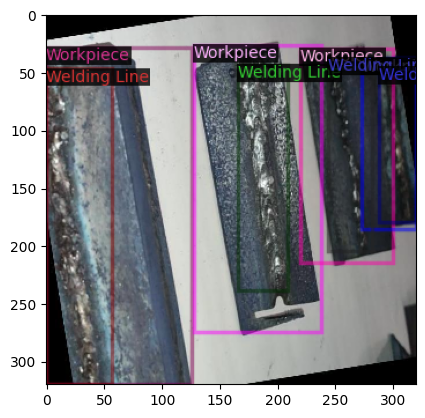

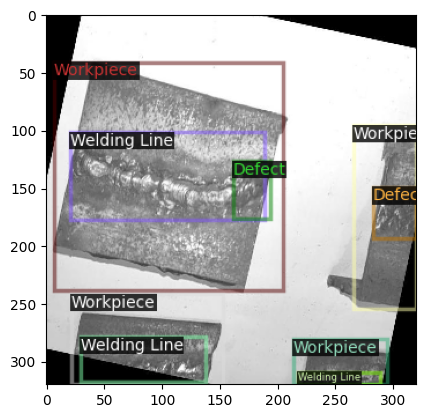

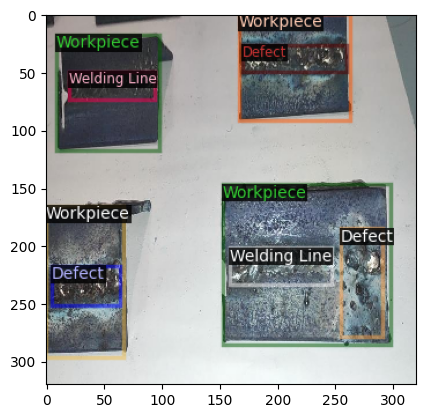

In [31]:
#visualize training data
import matplotlib.pyplot as plt
my_dataset_train_metadata = MetadataCatalog.get("my_dataset_train")
dataset_dicts = DatasetCatalog.get("my_dataset_train")

import random
from detectron2.utils.visualizer import Visualizer

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=my_dataset_train_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.show()

In [32]:
from detectron2.engine import DefaultTrainer
from detectron2.evaluation import COCOEvaluator

class CocoTrainer(DefaultTrainer):

  @classmethod
  def build_evaluator(cls, cfg, dataset_name, output_folder=None):

    if output_folder is None:
        os.makedirs("coco_eval", exist_ok=True)
        output_folder = "coco_eval"

    return COCOEvaluator(dataset_name, cfg, False, output_folder)

In [34]:
import torch
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog
import os

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [58]:
#Update the configuration to use the GPU:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",)
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.001
cfg.SOLVER.WARMUP_ITERS = 1000
cfg.SOLVER.MAX_ITER = 10000  # adjust up if val mAP is still rising, adjust down if overfit
cfg.SOLVER.STEPS = (1000, 1500)
cfg.SOLVER.GAMMA = 0.05
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 64
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # your number of classes + 1
cfg.TEST.EVAL_PERIOD = 500
cfg.num_updates = 2000

# Set the device for training
cfg.MODEL.DEVICE = str(device)  # Set the device for training

In [59]:
# Get the metadata for your datasets
MetadataCatalog.get("my_dataset_train")
MetadataCatalog.get("my_dataset_val")

namespace(name='my_dataset_val',
          json_file='data\\AI\\Model\\Crawl_Data\\valid\\_annotations.coco.json',
          image_root='data\\AI\\Model\\Crawl_Data\\valid',
          evaluator_type='coco',
          thing_classes=['weld', 'Defect', 'Welding Line', 'Workpiece'],
          thing_dataset_id_to_contiguous_id={0: 0, 1: 1, 2: 2, 3: 3})

In [ ]:
# neptune.init_run(
#     api_token=neptune.ANONYMOUS_API_TOKEN,
#     project="common/detectron2-integration",
# )

In [60]:
#Create the trainer and start training
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[05/07 18:13:04 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (5, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (5,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (16, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (16,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, 

[05/07 18:13:04 d2.engine.train_loop]: Starting training from iteration 0
[05/07 18:13:14 d2.utils.events]:  eta: 1:03:24  iter: 19  total_loss: 3.981  loss_cls: 1.676  loss_box_reg: 0.9496  loss_rpn_cls: 1.138  loss_rpn_loc: 0.1405    time: 0.3808  last_time: 0.4114  data_time: 0.1028  last_data_time: 0.0018   lr: 1.931e-06  max_mem: 7812M
[05/07 18:13:22 d2.utils.events]:  eta: 1:03:16  iter: 39  total_loss: 3.849  loss_cls: 1.634  loss_box_reg: 0.9608  loss_rpn_cls: 1.097  loss_rpn_loc: 0.1575    time: 0.3835  last_time: 0.3591  data_time: 0.0015  last_data_time: 0.0011   lr: 2.911e-06  max_mem: 7812M
[05/07 18:13:30 d2.utils.events]:  eta: 1:03:22  iter: 59  total_loss: 3.35  loss_cls: 1.536  loss_box_reg: 0.9655  loss_rpn_cls: 0.7112  loss_rpn_loc: 0.09847    time: 0.3842  last_time: 0.3844  data_time: 0.0014  last_data_time: 0.0015   lr: 3.891e-06  max_mem: 7812M
[05/07 18:13:38 d2.utils.events]:  eta: 1:05:08  iter: 79  total_loss: 3.071  loss_cls: 1.434  loss_box_reg: 0.9934  l

In [61]:
# Look at training curves in tensorboard:
%load_ext tensorboard
%tensorboard --logdir output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 13072), started 3:55:07 ago. (Use '!kill 13072' to kill it.)

In [63]:
#test evaluation
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_0009999.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.85
predictor = DefaultPredictor(cfg)
evaluator = COCOEvaluator("my_dataset_test", cfg, False, output_dir="./output/")
val_loader = build_detection_test_loader(cfg, "my_dataset_test")
inference_on_dataset(trainer.model, val_loader, evaluator)

[05/07 20:53:54 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output\model_0009999.pth ...
WARNING [05/07 20:53:55 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [05/07 20:53:55 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/07 20:53:55 d2.data.datasets.coco]: Loaded 258 images in COCO format from data\AI\Model\Crawl_Data\test\_annotations.coco.json
[05/07 20:53:55 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[05/07 20:53:55 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/07 20:53:55 d2.data.common]: Serializing 258 elements to byte tensors and concatenating them all ...
[05/07 20:53:55 d2.data.common]: Seria

OrderedDict([('bbox',
              {'AP': 39.23846751265941,
               'AP50': 62.2182357619975,
               'AP75': 39.47048175103573,
               'APs': 0.04292014695173727,
               'APm': 24.45806427625063,
               'APl': 40.7562997907822,
               'AP-weld': nan,
               'AP-Defect': 2.8292643292372412,
               'AP-Welding Line': 36.71055934789321,
               'AP-Workpiece': 78.17557886084779})])

: 

In [47]:
pwd

'd:\\nhan\\viko\\VIKO_UltraRobot'

In [42]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.DATASETS.TEST = ("my_dataset_test", )
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set the testing threshold for this model
predictor = DefaultPredictor(cfg)
test_metadata = MetadataCatalog.get("my_dataset_test")

[05/07 17:00:42 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output\model_final.pth ...


In [ ]:
from detectron2.utils.visualizer import ColorMode
import glob

for imageName in glob.glob('data\AI\Model\Crawl_Data\\test_sample/*png'):
    im = cv2.imread(imageName)
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                metadata=test_metadata,
                scale=0.8
                    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.imshow(out.get_image()[:, :, ::-1])
    plt.show()

Image Name: data/AI/Record_2024-05-03/20240503-210703206253-acA2440-35uc_22481496.png and Time: 0:00:00.358000s


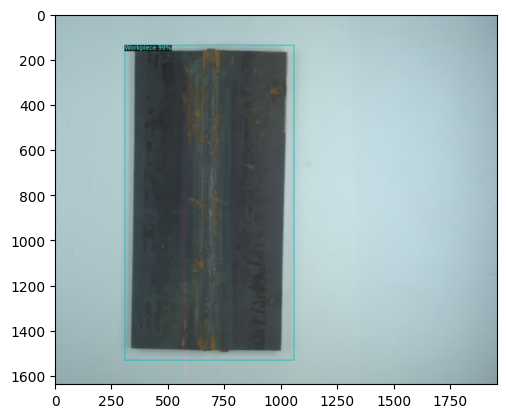

In [55]:
from detectron2.utils.visualizer import ColorMode
import glob

# for imageName in glob.glob('data\AI\Model\Crawl_Data\\test/*jpg'):
from datetime import datetime

start = datetime.now()
imageName = "data/AI/Record_2024-05-03/20240503-210703206253-acA2440-35uc_22481496.png"
im = cv2.imread(imageName)
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1],
            metadata=test_metadata,
            scale=0.8
                )
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
print(f'Image Name: {imageName} and Time: {datetime.now() - start}s')
plt.imshow(out.get_image()[:, :, ::-1])
plt.show()

In [4]:
pwd

'd:\\nhan\\viko\\VIKO_UltraRobot\\src'

In [5]:
%cd ..

d:\nhan\viko\VIKO_UltraRobot


In [7]:
import cv2
import numpy as np
import torch
import os
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import ColorMode, Visualizer
from detectron2.data import MetadataCatalog

# Load the pre-trained model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml"))
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml")  # Let training initialize from model zoo

# Set the device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.MODEL.DEVICE = str(device)

# Set the path to your trained model weights
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.DATASETS.TEST = ("my_dataset_test", )
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set the testing threshold for this model

predictor = DefaultPredictor(cfg)
test_metadata = MetadataCatalog.get("my_dataset_test")

# Open the video file
video_path = "path/to/your/video/file.mp4"  # Replace with the actual path to your video file
cap = cv2.VideoCapture(video_path)

while True:
    # Read a frame from the video
    ret, frame = cap.read()

    # Check if the video has ended
    if not ret:
        break

    # Run object detection on the frame
    outputs = predictor(frame)

    # Visualize the predictions
    v = Visualizer(frame[:, :, ::-1], metadata=predictor.metadata, instance_mode=ColorMode.IMAGE_BW)
    output_frame = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    output_frame = output_frame.get_image()[:, :, ::-1]

    # Display the output
    cv2.imshow("Object Detection", output_frame)

    # Exit the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and close the window
cap.release()
cv2.destroyAllWindows()

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (5, 1024) in the checkpoint but (81, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (5,) in the checkpoint but (81,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (16, 1024) in the checkpoint but (320, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (16,) in the checkpoint but (320,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, 

AttributeError: 'NoneType' object has no attribute 'shape'

In [50]:
from datetime import datetime
datetime.now()

datetime.datetime(2024, 5, 7, 17, 53, 1, 195221)